# Fairness analyses

Kendra Wyant  
June 11, 2024

### Set Up Environment

In [ ]:
#| message: false
#| warning: false

# handle conflicts
options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_ml.R?raw=true")

ℹ SHA-1 hash of file is "77e91675366f10788c6bcb59fa1cfc9ee0c75281"

In [ ]:
#| message: false
#| warning: false

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──
✔ broom        1.0.6      ✔ rsample      1.2.1 
✔ dials        1.2.1      ✔ tune         1.2.1 
✔ infer        1.0.7      ✔ workflows    1.1.4 
✔ modeldata    1.3.0      ✔ workflowsets 1.1.0 
✔ parsnip      1.2.1      ✔ yardstick    1.3.1 
✔ recipes      1.0.10     
── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Use tidymodels_prefer() to resolve common conflicts.

In [ ]:
#| output: false

devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true")

ℹ SHA-1 hash of file is "a58e57da996d1b70bb9a5b58241325d6fd78890f"

ℹ SHA-1 hash of file is "75cc6f7b855da59c240908bd936834b4da01285b"

In [ ]:
path_processed <- format_path(str_c("studydata/risk/data_processed/lag"))
path_models_lag <- format_path(str_c("studydata/risk/models/lag"))

### Read in Model Performance Metrics

In [ ]:
auroc_dem_0 <- read_csv(here::here(path_models_lag, "test_auroc_dem_1week_0_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)


auroc_dem_24 <- read_csv(here::here(path_models_lag, "test_auroc_dem_1week_24_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_72 <- read_csv(here::here(path_models_lag, "test_auroc_dem_1week_72_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_168 <- read_csv(here::here(path_models_lag, "test_auroc_dem_1week_168_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

auroc_dem_336 <- read_csv(here::here(path_models_lag, "test_auroc_dem_1week_336_v1_nested.csv"),
                      col_types = cols()) |> 
  mutate(fold_num = rep(1:10, 3),
         repeat_num = c(rep(1, 10), rep(2, 10), rep(3, 10))) |> 
  select(-outer_split_num)

### Get Median Posterior Probabilities and CIs

Sex

In [ ]:
#| output: false

for (lead in c(0,24,72,168,336)) {
  data_name <- str_c("auroc_dem_", lead)
  set.seed(101)
  pp <- get(data_name) |> 
    select(repeat_num, fold_num, female, male) |> 
    rename(id = repeat_num,
           id2 = fold_num) |> 
    perf_mod(formula = statistic ~ model + (1 | id2/id),
             transform = tidyposterior::logit_trans,  
             iter = 2000, chains = 4,  
             adapt_delta = .99,
             family = gaussian) 

  pp_tidy <- pp |> 
    tidy(seed = 123)

  q = c(.025, .5, .975)
  ci <- pp_tidy |> 
    group_by(model) |> 
    summarize(pp_median = quantile(posterior, probs = q[2]),
              pp_lower = quantile(posterior, probs = q[1]), 
              pp_upper = quantile(posterior, probs = q[3]))  |> 
    arrange(model)

  ci |> 
    write_csv(file.path(path_models_lag, str_c("pp_dem_sex_", lead, ".csv")))
  
  
  # contrasts
  ci_contrast <- pp |>
    contrast_models(list("male"), 
                    list("female")) |> 
  summary(size = 0) 
  
ci_median_contrast <- pp |> 
   contrast_models(list("male"), 
                  list("female")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) 


ci_contrast <- ci_contrast |> 
  mutate(contrast = "male vs. female") |> 
  left_join(ci_median_contrast, by = c("contrast")) |> 
  select(contrast, probability, median, lower, upper) 

ci_contrast |> 
  write_csv(file.path(path_models_lag, str_c("pp_dem_contrast_sex_", lead, ".csv")))
  }


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.1e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.61 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.726 seconds (Warm-up)
Chain 1:                0.547 seconds (Sampling)
Chain 1:                1.27

Race/Ethnicity

In [ ]:
#| output: false

for (lead in c(0,24,72,168,336)) {
  data_name <- str_c("auroc_dem_", lead)
  set.seed(101)
  pp <- get(data_name) |> 
    select(repeat_num, fold_num, `not white`, white) |> 
    rename(id = repeat_num,
           id2 = fold_num,
           `non-hispanic white` = white) |> 
    perf_mod(formula = statistic ~ model + (1 | id2/id),
             transform = tidyposterior::logit_trans,  
             iter = 2000, chains = 4,  
             adapt_delta = .99,
             family = gaussian) 

  pp_tidy <- pp |> 
    tidy(seed = 123)

  q = c(.025, .5, .975)
  ci <- pp_tidy |> 
    group_by(model) |> 
    summarize(pp_median = quantile(posterior, probs = q[2]),
              pp_lower = quantile(posterior, probs = q[1]), 
              pp_upper = quantile(posterior, probs = q[3]))  |> 
    arrange(model)

  ci |> 
    write_csv(file.path(path_models_lag, str_c("pp_dem_race_", lead, ".csv")))
  
  
  # contrasts
  ci_contrast <- pp |>
    contrast_models(list("non-hispanic white"), 
                    list("not white")) |> 
  summary(size = 0) 
  
ci_median_contrast <- pp |> 
   contrast_models(list("non-hispanic white"), 
                  list("not white")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) 


ci_contrast <- ci_contrast |> 
  mutate(contrast = "non-hispanic white vs. not white") |> 
  left_join(ci_median_contrast, by = c("contrast")) |> 
  select(contrast, probability, median, lower, upper) 

ci_contrast |> 
  write_csv(file.path(path_models_lag, str_c("pp_dem_contrast_race_", lead, ".csv")))
  }


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 2.5e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.25 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.749 seconds (Warm-up)
Chain 1:                0.682 seconds (Sampling)
Chain 1:                1.43

Income

In [ ]:
#| output: false

for (lead in c(0,24,72,168,336)) {
  data_name <- str_c("auroc_dem_", lead)
  set.seed(101)
  pp <- get(data_name) |> 
    select(repeat_num, fold_num, `below poverty`,`above poverty`) |> 
    rename(id = repeat_num,
           id2 = fold_num) |> 
    perf_mod(formula = statistic ~ model + (1 | id2/id),
             transform = tidyposterior::logit_trans,  
             iter = 2000, chains = 4,  
             adapt_delta = .99,
             family = gaussian) 

  pp_tidy <- pp |> 
    tidy(seed = 123)

  q = c(.025, .5, .975)
  ci <- pp_tidy |> 
    group_by(model) |> 
    summarize(pp_median = quantile(posterior, probs = q[2]),
              pp_lower = quantile(posterior, probs = q[1]), 
              pp_upper = quantile(posterior, probs = q[3]))  |> 
    arrange(model)

  ci |> 
    write_csv(file.path(path_models_lag, str_c("pp_dem_income_", lead, ".csv")))
  
  
  # contrasts
  ci_contrast <- pp |>
    contrast_models(list("above poverty"), 
                    list("below poverty")) |> 
  summary(size = 0) 
  
ci_median_contrast <- pp |> 
   contrast_models(list("above poverty"), 
                  list("below poverty")) |>  
  group_by(contrast) |> 
  summarize(median = quantile(difference, .5)) 


ci_contrast <- ci_contrast |> 
  mutate(contrast = "above poverty vs. below poverty") |> 
  left_join(ci_median_contrast, by = c("contrast")) |> 
  select(contrast, probability, median, lower, upper) 

ci_contrast |> 
  write_csv(file.path(path_models_lag, str_c("pp_dem_contrast_income_", lead, ".csv")))
  }


SAMPLING FOR MODEL 'continuous' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 2.3e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.23 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.608 seconds (Warm-up)
Chain 1:                0.398 seconds (Sampling)
Chain 1:                1.00

### Group comparisons

In [ ]:
#| echo: false

(contrast_0 <- read_csv(file.path(path_models_lag, "pp_dem_contrast_sex_0.csv"), col_types = cols()) |> 
    bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_race_0.csv"), col_types = cols())) |> 
    bind_rows(read_csv(file.path(path_models_lag, "pp_dem_contrast_income_0.csv"), col_types = cols())) |> 
  mutate(lag = "0 lag"))

# A tibble: 3 × 6
  contrast                         probability median  lower upper lag  
  <chr>                                  <dbl>  <dbl>  <dbl> <dbl> <chr>
1 male vs. female                         1.00 0.0701 0.0374 0.107 0 lag
2 non-hispanic white vs. not white        1    0.177  0.121  0.239 0 lag
3 above poverty vs. below poverty         1    0.157  0.0909 0.234 0 lag

# A tibble: 3 × 6
  contrast                         probability median  lower upper lag   
  <chr>                                  <dbl>  <dbl>  <dbl> <dbl> <chr> 
1 male vs. female                         1.00 0.0800 0.0467 0.115 24 lag
2 non-hispanic white vs. not white        1    0.209  0.149  0.276 24 lag
3 above poverty vs. below poverty         1.00 0.171  0.0929 0.260 24 lag

# A tibble: 3 × 6
  contrast                         probability median  lower upper lag   
  <chr>                                  <dbl>  <dbl>  <dbl> <dbl> <chr> 
1 male vs. female                         1    0.0905 0.0552 0.129 72 lag
2 non-hispanic white vs. not white        1    0.252  0.183  0.323 72 lag
3 above poverty vs. below poverty         1.00 0.183  0.101  0.274 72 lag

# A tibble: 3 × 6
  contrast                         probability median  lower upper lag    
  <chr>                                  <dbl>  <dbl>  <dbl> <dbl> <chr>  
1 male vs. female                            1  0.108 0.0729 0.149 168 lag
2 non-hispanic white vs. not white           1  0.249 0.181  0.324 168 lag
3 above poverty vs. below poverty            1  0.224 0.137  0.318 168 lag

# A tibble: 3 × 6
  contrast                         probability median  lower upper lag    
  <chr>                                  <dbl>  <dbl>  <dbl> <dbl> <chr>  
1 male vs. female                            1  0.126 0.0897 0.167 336 lag
2 non-hispanic white vs. not white           1  0.277 0.191  0.365 336 lag
3 above poverty vs. below poverty            1  0.268 0.184  0.354 336 lag

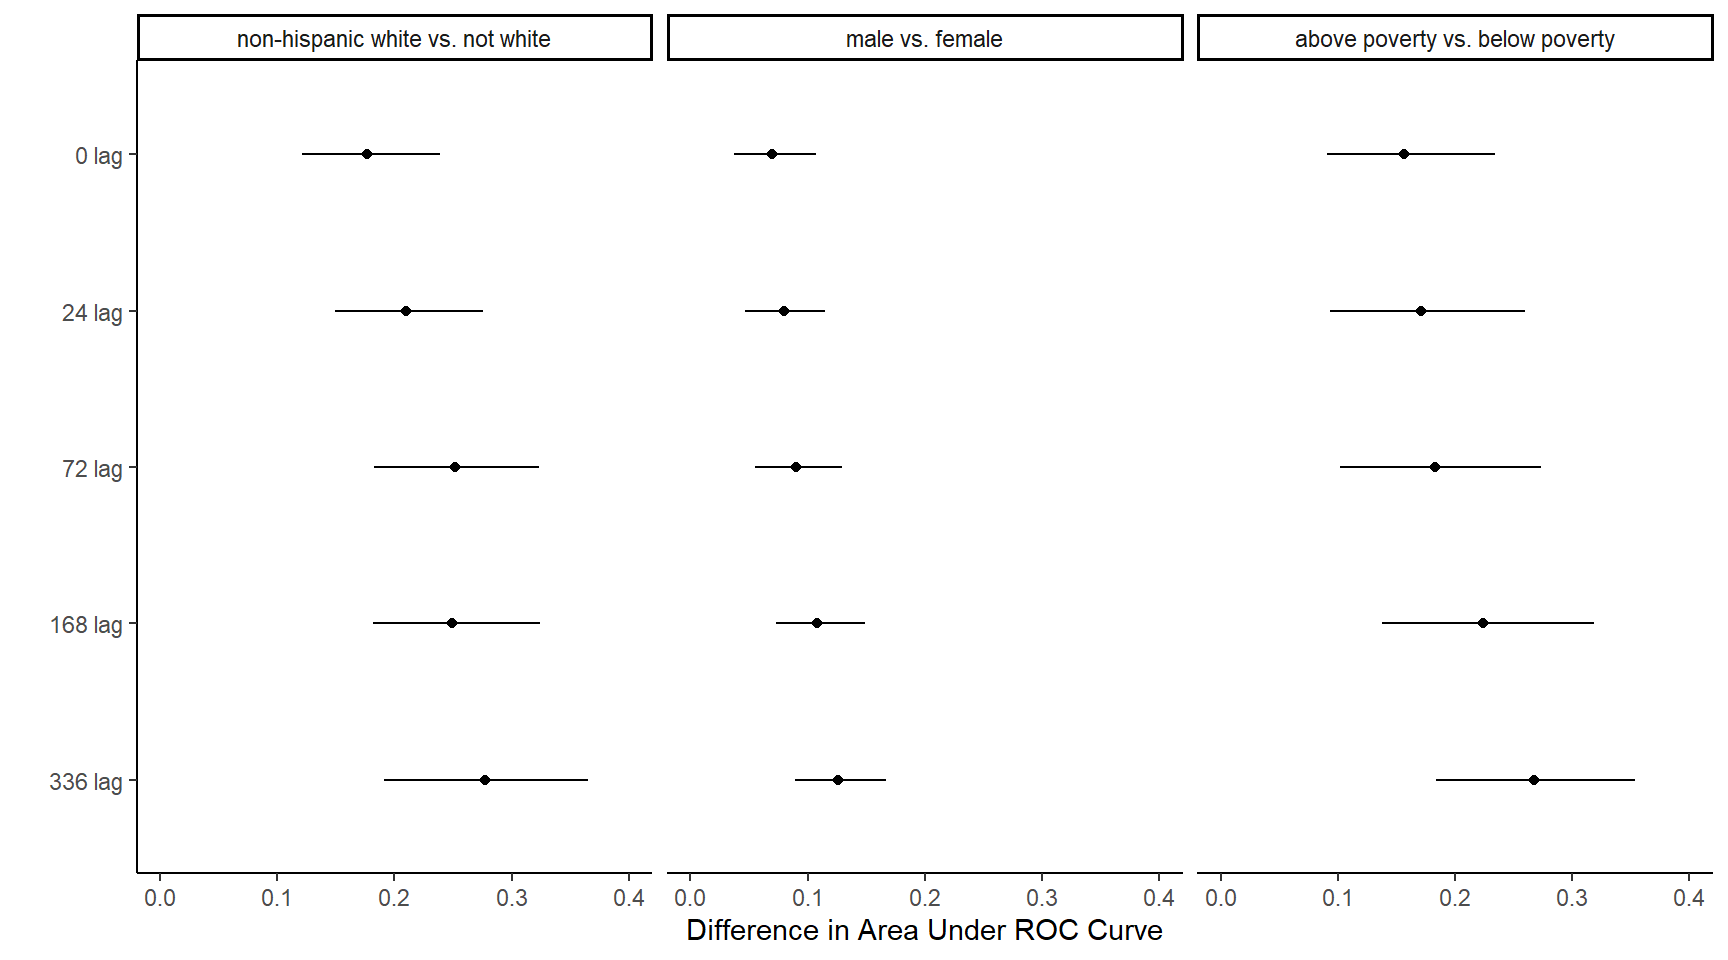

In [ ]:
#| echo: false
#| fig-width: 9

pp_dem_contrast |>
  mutate(lag = factor(lag, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
         contrast = factor(contrast, levels = c("non-hispanic white vs. not white",
                                                "male vs. female",
                                                "above poverty vs. below poverty"))) |> 
  ggplot() + 
  geom_point(aes(x = median, y = lag), color = "black") +
  geom_segment(mapping = aes(y = lag, x = lower, xend = upper),
                data = pp_dem_contrast |>
                 mutate(lag = factor(lag, levels = c("336 lag", "168 lag", "72 lag", "24 lag", "0 lag" )),
                 contrast = factor(contrast, levels = c("non-hispanic white vs. not white",
                                                "male vs. female",
                                                "above poverty vs. below poverty")))) +
  facet_grid(~contrast) +
  scale_x_continuous("Difference in Area Under ROC Curve", limits = c(0, .4), breaks = c(0, .1, .2, .3, .4)) +
  ylab("") +
  theme_classic() +
  theme(legend.position = "none")

### Results

All group comparisons for race, sex, and income were significant across models. On average there was a median increase in auROC for white participants compared to participants who were not white was (95% CI=\[-\]). On average there was a median increase in auROC for male participants compared to female participants was 0.070, 0.080, 0.090, 0.108, 0.126 (95% CI=\[0.037, 0.047, 0.055, 0.073, 0.090-0.107, 0.115, 0.129, 0.149, 0.167\]). On average there was a median increase in auROC for participants above the federal poverty line compared to participants below the federal poverty line was 0.157, 0.171, 0.183, 0.224, 0.268 (95% CI=\[0.091, 0.093, 0.101, 0.137, 0.184-0.234, 0.260, 0.274, 0.318, 0.354\]). <!-- Currently averaging across median auROC differences for each model. Also averaging lower and upper CI bounds - is this okay? Should I realculate CI based on average of averages?-->

Notably, the Bayesian CIs were wide and included chance performance as lag increased (i.e., 72 hours, 168 hours, and 336 hours) for individuals who were not white and with an income below the federal poverty line.

In [ ]:
#| echo: false

(pp_dem_0 <- read_csv(file.path(path_models_lag, "pp_dem_sex_0.csv"), col_types = cols()) |> 
    bind_rows(read_csv(file.path(path_models_lag, "pp_dem_race_0.csv"), col_types = cols())) |> 
    bind_rows(read_csv(file.path(path_models_lag, "pp_dem_income_0.csv"), col_types = cols())) |> 
  mutate(lag = "0 lag"))

# A tibble: 6 × 5
  model              pp_median pp_lower pp_upper lag  
  <chr>                  <dbl>    <dbl>    <dbl> <chr>
1 female                 0.850    0.806    0.884 0 lag
2 male                   0.920    0.893    0.941 0 lag
3 non-hispanic white     0.899    0.868    0.925 0 lag
4 not white              0.723    0.644    0.788 0 lag
5 above poverty          0.897    0.857    0.926 0 lag
6 below poverty          0.739    0.645    0.814 0 lag

# A tibble: 6 × 5
  model              pp_median pp_lower pp_upper lag   
  <chr>                  <dbl>    <dbl>    <dbl> <chr> 
1 female                 0.837    0.795    0.873 24 lag
2 male                   0.917    0.894    0.937 24 lag
3 non-hispanic white     0.893    0.860    0.919 24 lag
4 not white              0.683    0.600    0.755 24 lag
5 above poverty          0.888    0.844    0.920 24 lag
6 below poverty          0.716    0.604    0.805 24 lag

# A tibble: 6 × 5
  model              pp_median pp_lower pp_upper lag   
  <chr>                  <dbl>    <dbl>    <dbl> <chr> 
1 female                 0.818    0.768    0.859 72 lag
2 male                   0.909    0.880    0.931 72 lag
3 non-hispanic white     0.883    0.848    0.912 72 lag
4 not white              0.631    0.543    0.711 72 lag
5 above poverty          0.878    0.829    0.915 72 lag
6 below poverty          0.695    0.587    0.788 72 lag

# A tibble: 6 × 5
  model              pp_median pp_lower pp_upper lag    
  <chr>                  <dbl>    <dbl>    <dbl> <chr>  
1 female                 0.808    0.757    0.848 168 lag
2 male                   0.917    0.891    0.936 168 lag
3 non-hispanic white     0.876    0.837    0.907 168 lag
4 not white              0.626    0.537    0.707 168 lag
5 above poverty          0.878    0.832    0.912 168 lag
6 below poverty          0.652    0.541    0.753 168 lag

# A tibble: 6 × 5
  model              pp_median pp_lower pp_upper lag    
  <chr>                  <dbl>    <dbl>    <dbl> <chr>  
1 female                 0.773    0.726    0.813 336 lag
2 male                   0.899    0.875    0.920 336 lag
3 non-hispanic white     0.854    0.803    0.895 336 lag
4 not white              0.576    0.469    0.678 336 lag
5 above poverty          0.859    0.813    0.895 336 lag
6 below poverty          0.591    0.483    0.692 336 lag